# Lecture A08: MCMC and Item Response Models

Companion notebook for [[Lecture A08 - MCMC and Item Response Models]]. Prerequisites: [[A01|A01]] through [[A07|A07]].

**Part 1** — Lecture walkthrough: Metropolis algorithm implementation, HMC implementation, trace plot diagnostics, R-hat and ESS, simulated IRT wine model

**Part 2** — Applied exercises: Metropolis on real estate Beta-Binomial, IRT for forensic device calibration, MCMC diagnostics on municipality model, IRT for property appraisal simulation

**Convention:** 89% credible intervals. Multiple chains for convergence assessment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 150,
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

C_PRIOR = "#9ca3af"
C_POSTERIOR = "#2563eb"
C_LIKELIHOOD = "#dc2626"
C_DATA = "#059669"
C_ACCENT = "#d97706"
C_POINT = "#111827"
C_PURPLE = "#7c3aed"
CHAIN_COLORS = [C_POSTERIOR, C_LIKELIHOOD, C_DATA, C_ACCENT]

DATA_DIR = Path("../data")
CI_LEVEL = 0.89
N_SAMPLES = 5_000

---

# Part 1: Lecture Walkthrough

## 1. The Metropolis Algorithm

The simplest MCMC sampler. Propose, evaluate, accept/reject. Not gradient-based. The acceptance rate is the key diagnostic: ~23% optimal for high dimensions.

Acceptance rate: 57.04%


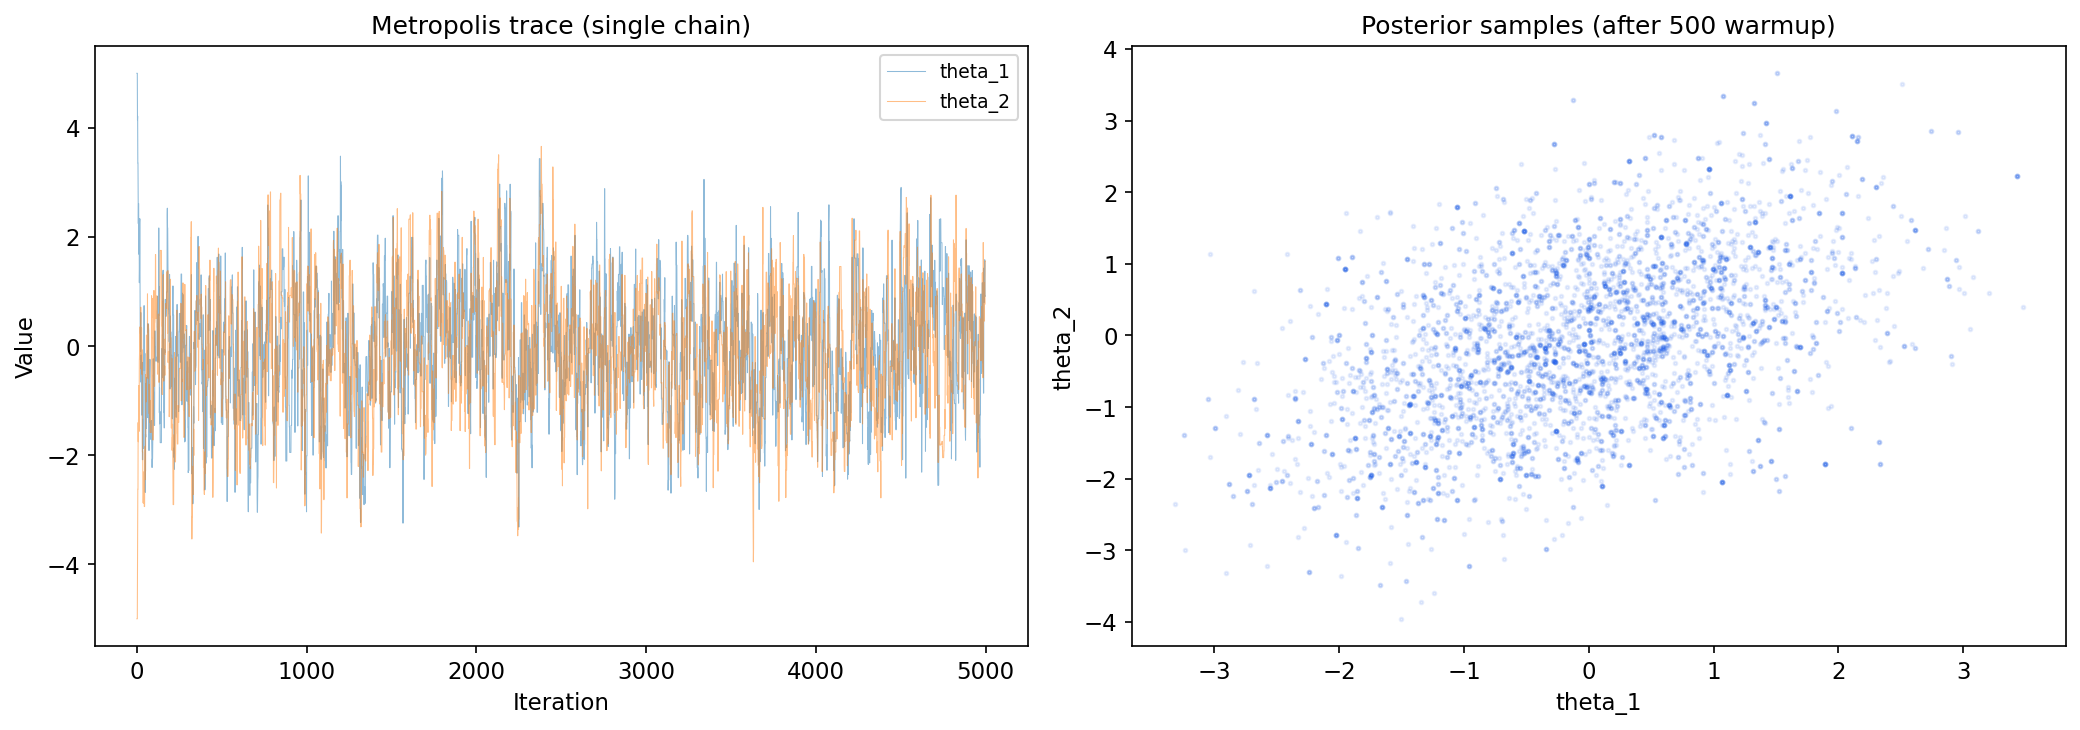

In [2]:
def metropolis(
    log_posterior_fn,
    initial: np.ndarray,
    n_samples: int = 5_000,
    proposal_sd: float = 0.1,
    seed: int = SEED,
) -> np.ndarray:
    """Run the Metropolis algorithm.

    Args:
        log_posterior_fn: Function returning log posterior at theta.
        initial: Starting parameter values.
        n_samples: Number of MCMC samples.
        proposal_sd: SD of Gaussian proposal.
        seed: Random seed.

    Returns:
        Array of shape (n_samples, n_params).
    """
    rng = np.random.default_rng(seed)
    n_params = len(initial)
    samples = np.zeros((n_samples, n_params))
    current = initial.copy()
    current_lp = log_posterior_fn(current)
    n_accepted = 0

    for i in range(n_samples):
        proposal = current + rng.normal(0, proposal_sd, size=n_params)
        proposal_lp = log_posterior_fn(proposal)
        log_ratio = proposal_lp - current_lp
        if np.log(rng.random()) < log_ratio:
            current = proposal
            current_lp = proposal_lp
            n_accepted += 1
        samples[i] = current

    print(f"Acceptance rate: {n_accepted / n_samples:.2%}")
    return samples


# Demo: sample from a 2D Gaussian posterior
def log_posterior_demo(theta):
    """Log posterior for a bivariate normal (mean=0, correlated)."""
    mu = np.array([0.0, 0.0])
    cov_inv = np.array([[1.0, -0.5], [-0.5, 1.0]])
    diff = theta - mu
    return -0.5 * diff @ cov_inv @ diff

samples_metro = metropolis(log_posterior_demo, np.array([5.0, -5.0]),
                            n_samples=N_SAMPLES, proposal_sd=1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trace
for i, name in enumerate(["theta_1", "theta_2"]):
    axes[0].plot(samples_metro[:, i], alpha=0.5, linewidth=0.5, label=name)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Value")
axes[0].set_title("Metropolis trace (single chain)")
axes[0].legend(fontsize=9)

# Scatter
axes[1].scatter(samples_metro[500:, 0], samples_metro[500:, 1], alpha=0.1, s=3, color=C_POSTERIOR)
axes[1].set_xlabel("theta_1"); axes[1].set_ylabel("theta_2")
axes[1].set_title("Posterior samples (after 500 warmup)")

plt.tight_layout()
plt.show()

## 2. Hamiltonian Monte Carlo (HMC)

Uses gradients to make informed proposals. The ball-on-a-surface analogy: random kick, leapfrog integration, Metropolis accept/reject on the Hamiltonian.

HMC acceptance rate: 100.00%


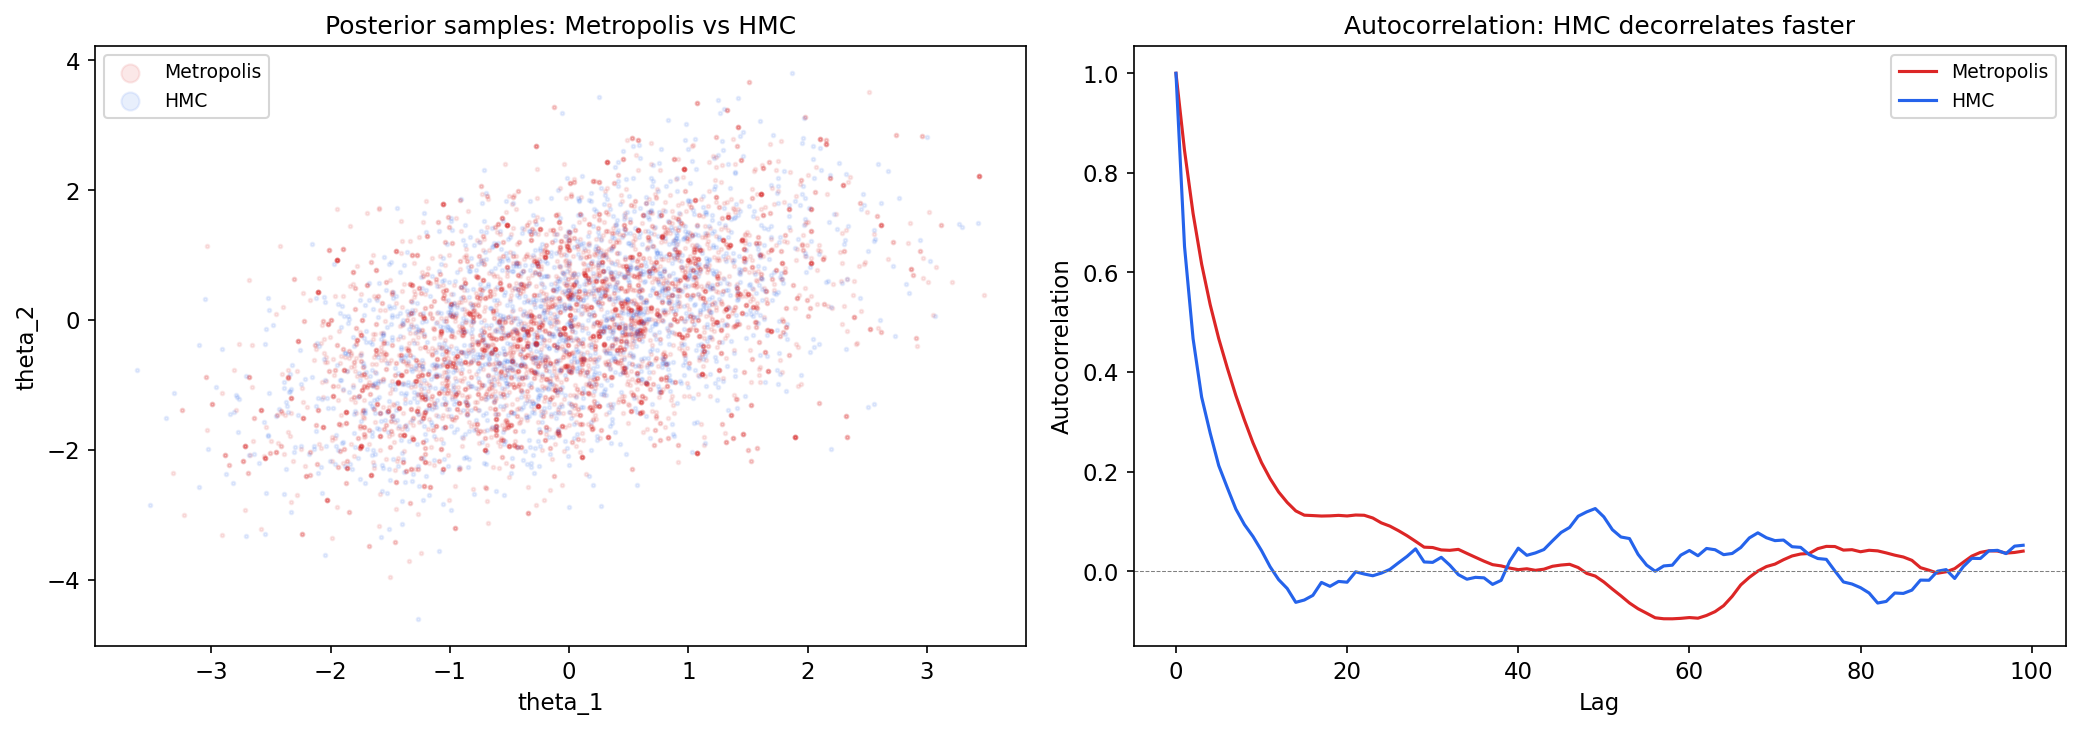

HMC produces nearly independent samples (ACF drops quickly).
Metropolis has high autocorrelation (slow random walk).


In [3]:
def hmc(
    log_posterior_fn,
    grad_log_posterior_fn,
    initial: np.ndarray,
    n_samples: int = 2_000,
    step_size: float = 0.05,
    n_leapfrog: int = 20,
    seed: int = SEED,
) -> np.ndarray:
    """Simplified Hamiltonian Monte Carlo.

    Args:
        log_posterior_fn: Log posterior function.
        grad_log_posterior_fn: Gradient of log posterior.
        initial: Starting values.
        n_samples: Number of samples.
        step_size: Leapfrog epsilon.
        n_leapfrog: Leapfrog steps per proposal.
        seed: Random seed.

    Returns:
        Array of shape (n_samples, n_params).
    """
    rng = np.random.default_rng(seed)
    n_params = len(initial)
    samples = np.zeros((n_samples, n_params))
    current = initial.copy()
    n_accepted = 0

    for i in range(n_samples):
        momentum = rng.normal(0, 1, size=n_params)
        current_momentum = momentum.copy()
        proposal = current.copy()
        p = momentum.copy()

        p += 0.5 * step_size * grad_log_posterior_fn(proposal)
        for _ in range(n_leapfrog - 1):
            proposal += step_size * p
            p += step_size * grad_log_posterior_fn(proposal)
        proposal += step_size * p
        p += 0.5 * step_size * grad_log_posterior_fn(proposal)

        current_H = -log_posterior_fn(current) + 0.5 * np.sum(current_momentum**2)
        proposal_H = -log_posterior_fn(proposal) + 0.5 * np.sum(p**2)

        if np.log(rng.random()) < current_H - proposal_H:
            current = proposal
            n_accepted += 1
        samples[i] = current

    print(f"HMC acceptance rate: {n_accepted / n_samples:.2%}")
    return samples


def grad_log_posterior_demo(theta):
    """Gradient for the bivariate normal demo."""
    cov_inv = np.array([[1.0, -0.5], [-0.5, 1.0]])
    return -cov_inv @ theta

samples_hmc = hmc(log_posterior_demo, grad_log_posterior_demo,
                   np.array([5.0, -5.0]), n_samples=2000)

# Compare Metropolis vs HMC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(samples_metro[500:, 0], samples_metro[500:, 1], alpha=0.1, s=3, color=C_LIKELIHOOD, label="Metropolis")
axes[0].scatter(samples_hmc[200:, 0], samples_hmc[200:, 1], alpha=0.1, s=3, color=C_POSTERIOR, label="HMC")
axes[0].set_title("Posterior samples: Metropolis vs HMC")
axes[0].legend(fontsize=9, markerscale=5)
axes[0].set_xlabel("theta_1"); axes[0].set_ylabel("theta_2")

# Autocorrelation comparison
for ax_i, (samp, name, color) in enumerate([
    (samples_metro[500:, 0], "Metropolis", C_LIKELIHOOD),
    (samples_hmc[200:, 0], "HMC", C_POSTERIOR),
]):
    acf = np.correlate(samp - samp.mean(), samp - samp.mean(), mode="full")
    acf = acf[len(acf)//2:] / acf[len(acf)//2]
    axes[1].plot(acf[:100], color=color, linewidth=1.5, label=name)

axes[1].set_xlabel("Lag"); axes[1].set_ylabel("Autocorrelation")
axes[1].set_title("Autocorrelation: HMC decorrelates faster")
axes[1].legend(fontsize=9)
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

print("HMC produces nearly independent samples (ACF drops quickly).")
print("Metropolis has high autocorrelation (slow random walk).")

## 3. MCMC Diagnostics: Trace Plots, R-hat, ESS

Three non-negotiable checks:
- **Trace plots:** hairy caterpillar = good. Trends/plateaus = bad.
- **$\hat{R} < 1.01$:** chains agree with each other.
- **ESS > 400:** enough effective independent samples.

We run multiple chains from different starting points to verify convergence.

In [4]:
def run_multi_chain(
    log_posterior_fn,
    n_chains: int = 4,
    n_samples: int = 3_000,
    proposal_sd: float = 1.0,
    seed: int = SEED,
) -> np.ndarray:
    """Run multiple Metropolis chains from dispersed starting points.

    Args:
        log_posterior_fn: Log posterior function.
        n_chains: Number of chains.
        n_samples: Samples per chain.
        proposal_sd: Proposal standard deviation.
        seed: Base random seed.

    Returns:
        Array of shape (n_chains, n_samples, n_params).
    """
    rng = np.random.default_rng(seed)
    all_chains = []
    for c in range(n_chains):
        start = rng.normal(0, 3, size=2)  # dispersed starts
        chain = metropolis(log_posterior_fn, start,
                           n_samples=n_samples, proposal_sd=proposal_sd,
                           seed=seed + c + 1)
        all_chains.append(chain)
    return np.array(all_chains)


def compute_rhat(chains: np.ndarray, warmup: int = 500) -> float:
    """Compute R-hat for a single parameter across chains.

    Args:
        chains: Array of shape (n_chains, n_samples).
        warmup: Samples to discard.

    Returns:
        R-hat value (should be < 1.01).
    """
    post = chains[:, warmup:]
    n_chains, n_samples = post.shape
    chain_means = post.mean(axis=1)
    grand_mean = chain_means.mean()
    B = n_samples * np.var(chain_means, ddof=1)  # between-chain
    W = np.mean(np.var(post, axis=1, ddof=1))    # within-chain
    var_hat = (1 - 1/n_samples) * W + B / n_samples
    return np.sqrt(var_hat / W)


def compute_ess(chain: np.ndarray) -> float:
    """Estimate effective sample size from autocorrelation.

    Args:
        chain: 1D array of samples.

    Returns:
        Effective sample size.
    """
    n = len(chain)
    acf = np.correlate(chain - chain.mean(), chain - chain.mean(), mode="full")
    acf = acf[n-1:] / acf[n-1]
    # Sum pairs of consecutive autocorrelations until negative
    tau = 1.0
    for k in range(1, n // 2):
        rho = acf[k]
        if rho < 0:
            break
        tau += 2 * rho
    return n / tau


# Run 4 chains
print("Running 4 chains...")
multi_chains = run_multi_chain(log_posterior_demo, n_chains=4, n_samples=3000)

Running 4 chains...
Acceptance rate: 57.10%
Acceptance rate: 56.77%
Acceptance rate: 55.67%
Acceptance rate: 56.83%


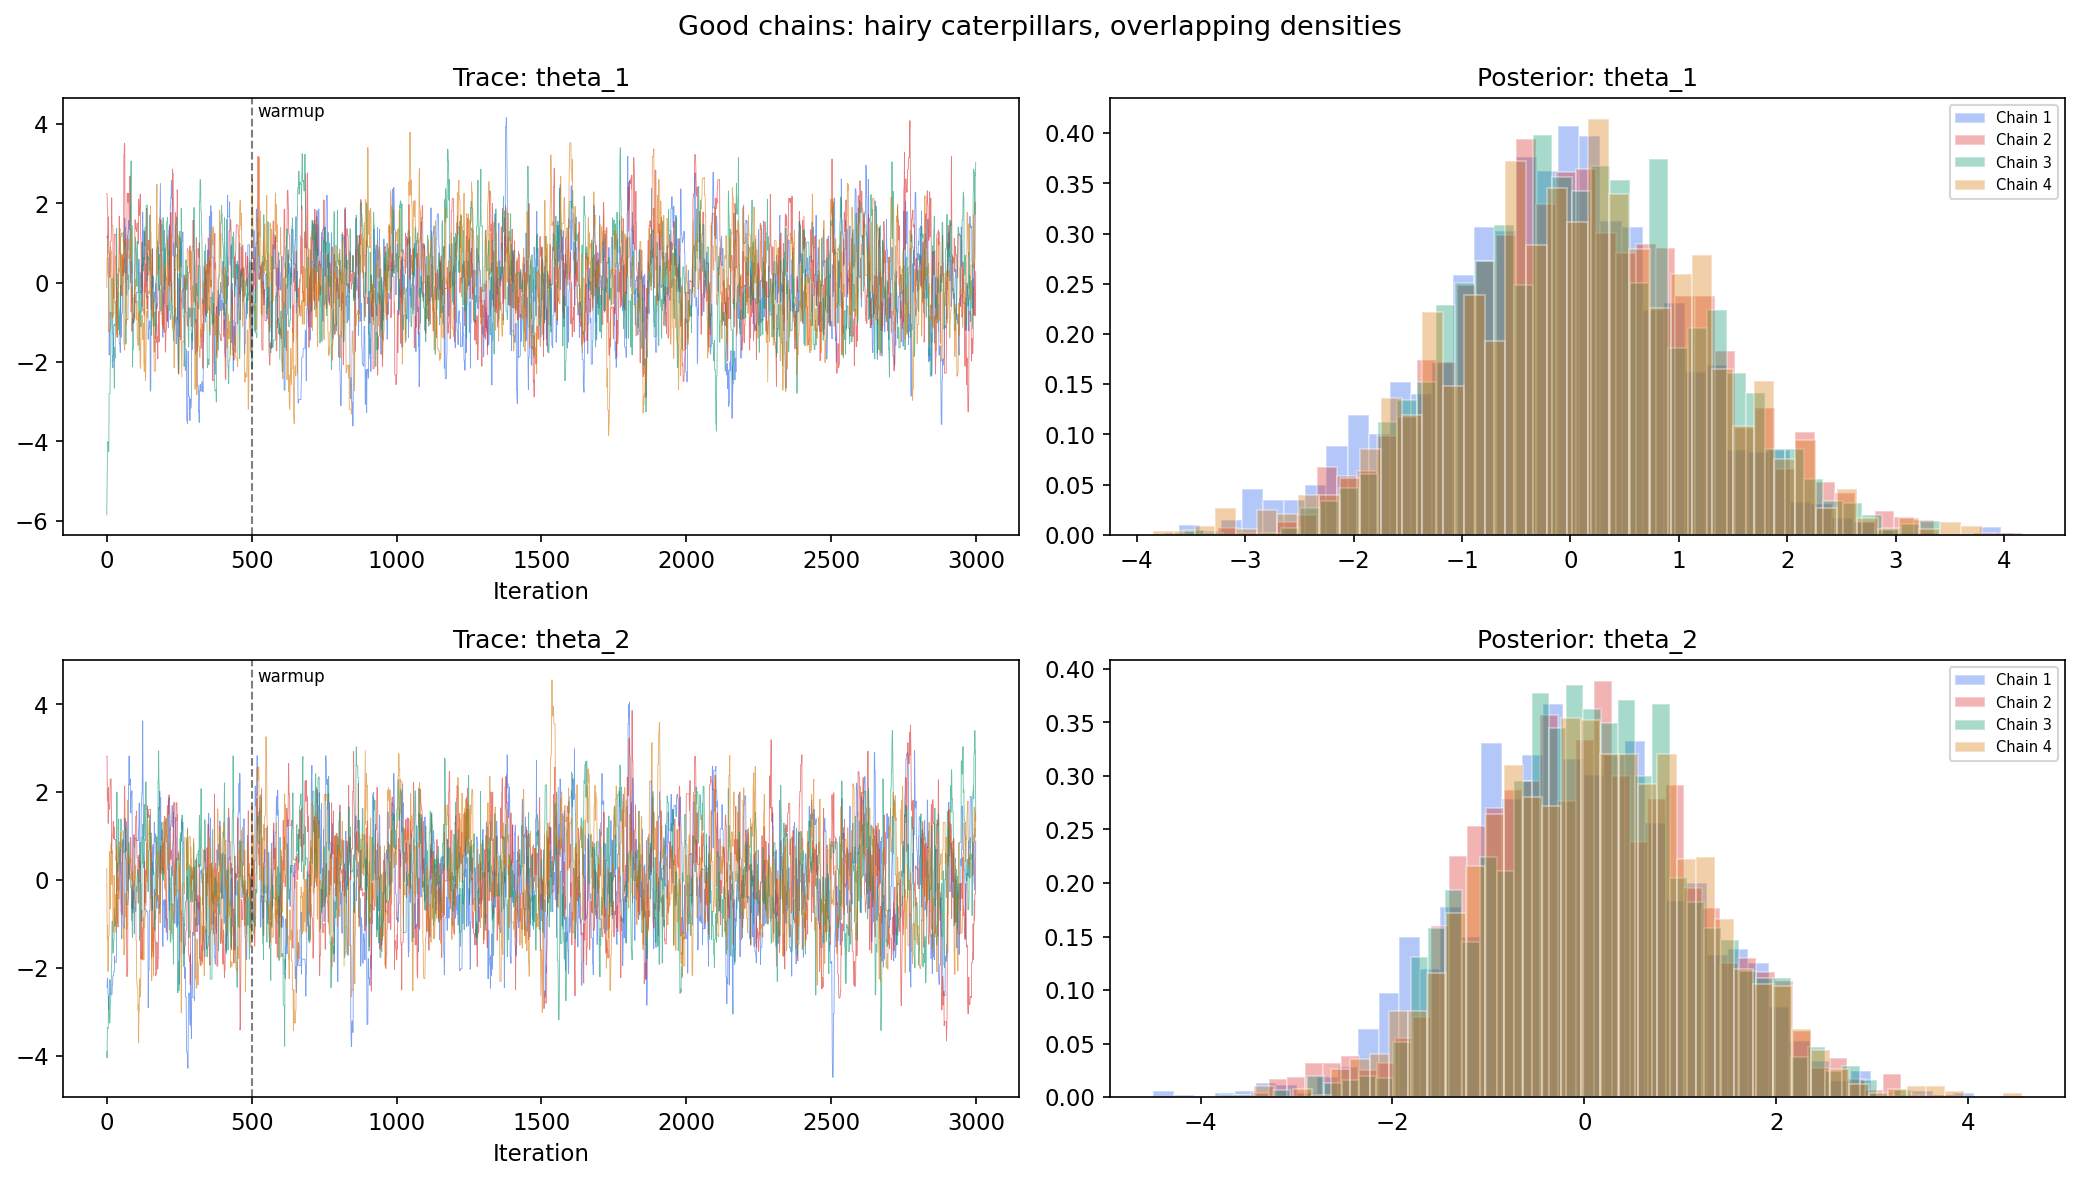

theta_1: R-hat = 1.0062, mean ESS = 179
theta_2: R-hat = 1.0020, mean ESS = 183

R-hat < 1.01: chains converged. ESS > 400: reliable summaries.


In [5]:
# Trace plots + diagnostics
warmup = 500
param_names = ["theta_1", "theta_2"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for p in range(2):
    # Trace
    ax = axes[p, 0]
    for c in range(4):
        ax.plot(multi_chains[c, :, p], alpha=0.6, linewidth=0.4, color=CHAIN_COLORS[c])
    ax.axvline(warmup, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(f"Trace: {param_names[p]}")
    ax.set_xlabel("Iteration")
    ax.text(warmup + 20, ax.get_ylim()[1] * 0.9, "warmup", fontsize=8)

    # Density
    ax = axes[p, 1]
    for c in range(4):
        ax.hist(multi_chains[c, warmup:, p], bins=40, density=True, alpha=0.35,
                color=CHAIN_COLORS[c], edgecolor="white", label=f"Chain {c+1}")
    ax.set_title(f"Posterior: {param_names[p]}")
    ax.legend(fontsize=7)

plt.suptitle("Good chains: hairy caterpillars, overlapping densities", fontsize=13)
plt.tight_layout()
plt.show()

# R-hat and ESS
for p in range(2):
    rhat = compute_rhat(multi_chains[:, :, p], warmup=warmup)
    ess_vals = [compute_ess(multi_chains[c, warmup:, p]) for c in range(4)]
    avg_ess = np.mean(ess_vals)
    print(f"{param_names[p]}: R-hat = {rhat:.4f}, mean ESS = {avg_ess:.0f}")

print("\nR-hat < 1.01: chains converged. ESS > 400: reliable summaries.")

## 4. Bad Chains: What Non-Convergence Looks Like

Deliberately break the sampler (tiny proposal SD) to show what bad chains look like.

Running bad chains (proposal_sd=0.01)...
Acceptance rate: 98.67%
Acceptance rate: 99.37%
Acceptance rate: 98.60%
Acceptance rate: 99.40%


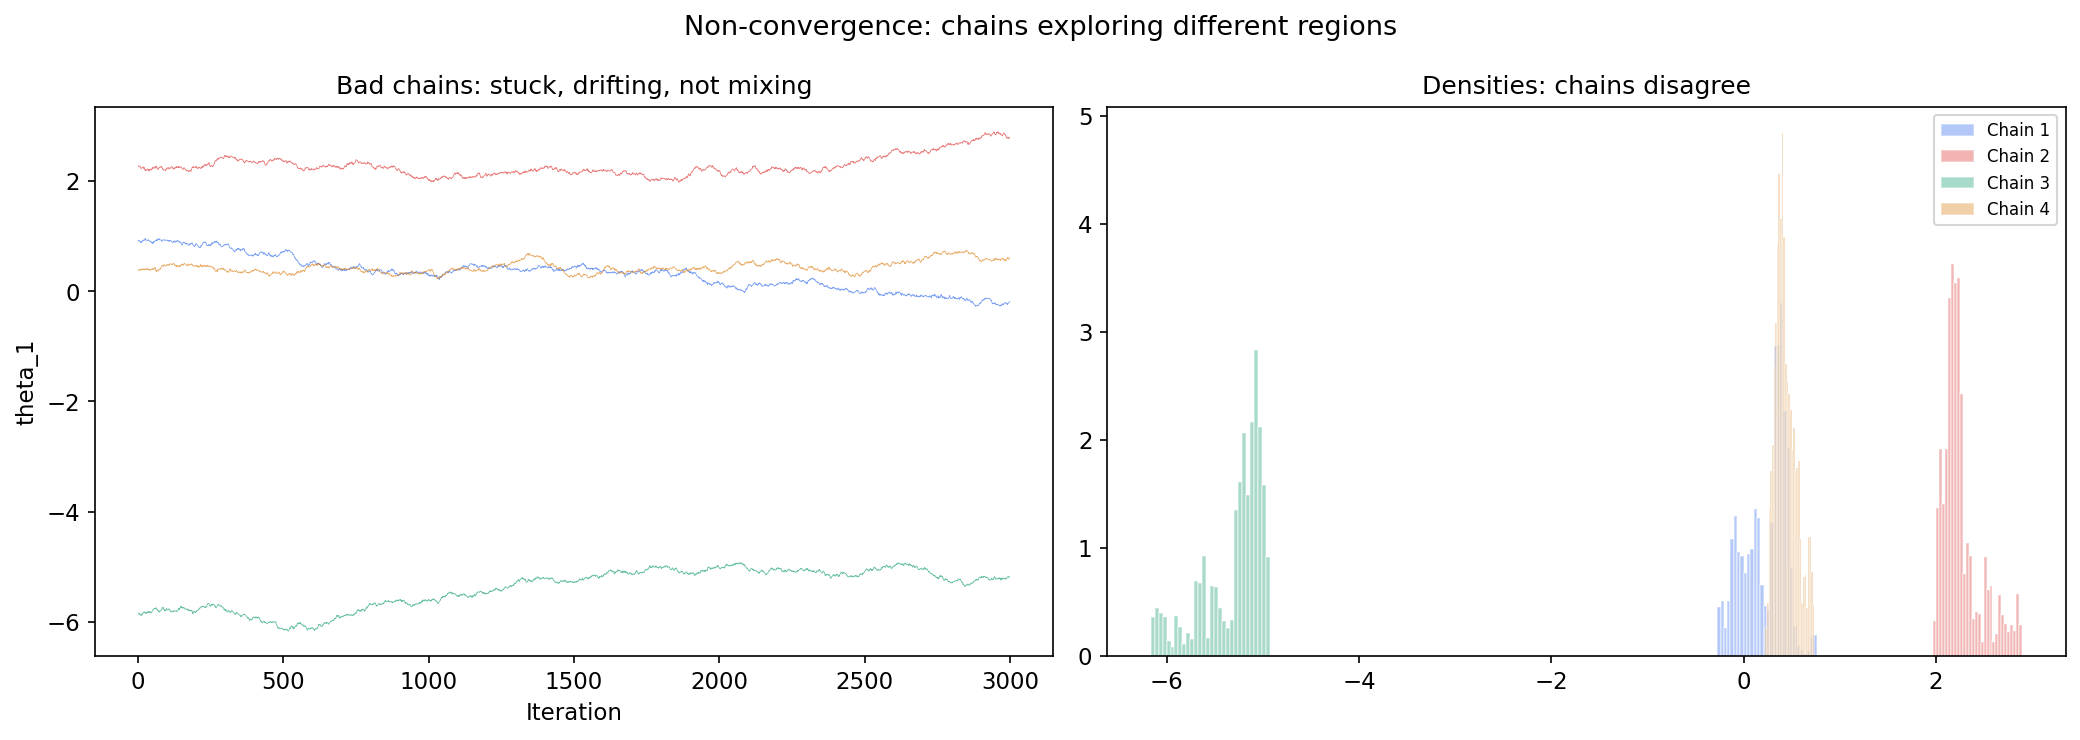

Bad chain R-hat = 14.5208 (should be < 1.01)
Bad chain ESS = 6 (should be > 400)
These diagnostics catch the problem before you interpret garbage.


In [6]:
# Bad chains: proposal_sd too small -> random walk, poor mixing
print("Running bad chains (proposal_sd=0.01)...")
bad_chains = run_multi_chain(log_posterior_demo, n_chains=4, n_samples=3000,
                              proposal_sd=0.01)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c in range(4):
    axes[0].plot(bad_chains[c, :, 0], alpha=0.6, linewidth=0.4, color=CHAIN_COLORS[c])
axes[0].set_title("Bad chains: stuck, drifting, not mixing")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("theta_1")

for c in range(4):
    axes[1].hist(bad_chains[c, warmup:, 0], bins=30, density=True, alpha=0.35,
                 color=CHAIN_COLORS[c], edgecolor="white", label=f"Chain {c+1}")
axes[1].set_title("Densities: chains disagree")
axes[1].legend(fontsize=8)

plt.suptitle("Non-convergence: chains exploring different regions", fontsize=13)
plt.tight_layout()
plt.show()

rhat_bad = compute_rhat(bad_chains[:, :, 0], warmup=warmup)
ess_bad = np.mean([compute_ess(bad_chains[c, warmup:, 0]) for c in range(4)])
print(f"Bad chain R-hat = {rhat_bad:.4f} (should be < 1.01)")
print(f"Bad chain ESS = {ess_bad:.0f} (should be > 400)")
print("These diagnostics catch the problem before you interpret garbage.")

## 5. Simulated Wine IRT Model

Simulate a blind wine tasting and fit the IRT model to recover latent wine quality and judge parameters.

$$\mu_i = D_{J[i]} \cdot Q_{W[i]} - H_{J[i]}$$
$$S_i \sim \text{Normal}(\mu_i, \sigma)$$

In [7]:
# Simulate wine tasting data
def sim_wine_tasting(
    n_wines: int = 20,
    n_judges: int = 9,
    seed: int = SEED,
) -> dict:
    """Simulate IRT wine tasting data.

    Args:
        n_wines: Number of wines.
        n_judges: Number of judges.
        seed: Random seed.

    Returns:
        Dict with scores, wine_idx, judge_idx, and true parameters.
    """
    rng = np.random.default_rng(seed)

    # True parameters
    Q_true = rng.normal(0, 1, size=n_wines)  # wine quality
    H_true = rng.normal(0, 0.8, size=n_judges)  # judge harshness
    D_true = rng.lognormal(0, 0.3, size=n_judges)  # judge discrimination
    sigma_true = 0.5

    # Each judge tastes each wine
    wine_idx = np.tile(np.arange(n_wines), n_judges)
    judge_idx = np.repeat(np.arange(n_judges), n_wines)

    mu = D_true[judge_idx] * Q_true[wine_idx] - H_true[judge_idx]
    scores = mu + rng.normal(0, sigma_true, size=len(mu))

    return {
        "scores": scores, "wine_idx": wine_idx, "judge_idx": judge_idx,
        "Q_true": Q_true, "H_true": H_true, "D_true": D_true,
        "sigma_true": sigma_true, "n_wines": n_wines, "n_judges": n_judges,
    }

wine_data = sim_wine_tasting()
print(f"Simulated {wine_data['n_wines']} wines x {wine_data['n_judges']} judges = {len(wine_data['scores'])} tastings")
print(f"True sigma = {wine_data['sigma_true']}")
print(f"True Q range: [{wine_data['Q_true'].min():.2f}, {wine_data['Q_true'].max():.2f}]")
print(f"True D range: [{wine_data['D_true'].min():.2f}, {wine_data['D_true'].max():.2f}]")

Simulated 20 wines x 9 judges = 180 tastings
True sigma = 0.5
True Q range: [-1.95, 1.13]
True D range: [0.78, 1.90]


In [8]:
# Fit IRT model via Metropolis on simplified version (fix D=1 for tractability)
# Full model with D would use HMC/PyMC; here we demonstrate the MCMC workflow

def log_posterior_wine(params, scores, wine_idx, judge_idx, n_wines, n_judges):
    """Log posterior for simplified wine IRT: mu = Q[w] - H[j]."""
    Q = params[:n_wines]
    H = params[n_wines:n_wines + n_judges]
    log_sigma = params[-1]
    sigma = np.exp(log_sigma)
    if sigma <= 0 or sigma > 10:
        return -np.inf

    mu = Q[wine_idx] - H[judge_idx]
    ll = np.sum(stats.norm.logpdf(scores, mu, sigma))
    lp = np.sum(stats.norm.logpdf(Q, 0, 1))  # prior on Q
    lp += np.sum(stats.norm.logpdf(H, 0, 1))  # prior on H
    lp += stats.expon.logpdf(sigma, scale=1) + log_sigma  # prior on sigma
    return ll + lp


n_w = wine_data["n_wines"]
n_j = wine_data["n_judges"]
n_params_wine = n_w + n_j + 1

def lp_wine(params):
    return log_posterior_wine(params, wine_data["scores"], wine_data["wine_idx"],
                              wine_data["judge_idx"], n_w, n_j)

# Run 2 chains (short for demo)
print("Fitting simplified wine IRT model (D=1, Metropolis)...")
chains_wine = []
for c in range(2):
    rng_c = np.random.default_rng(SEED + c + 10)
    start = rng_c.normal(0, 0.5, size=n_params_wine)
    start[-1] = np.log(0.5)
    chain = metropolis(lp_wine, start, n_samples=N_SAMPLES, proposal_sd=0.05,
                        seed=SEED + c + 10)
    chains_wine.append(chain)

chains_wine = np.array(chains_wine)

Fitting simplified wine IRT model (D=1, Metropolis)...
Acceptance rate: 32.72%
Acceptance rate: 34.22%


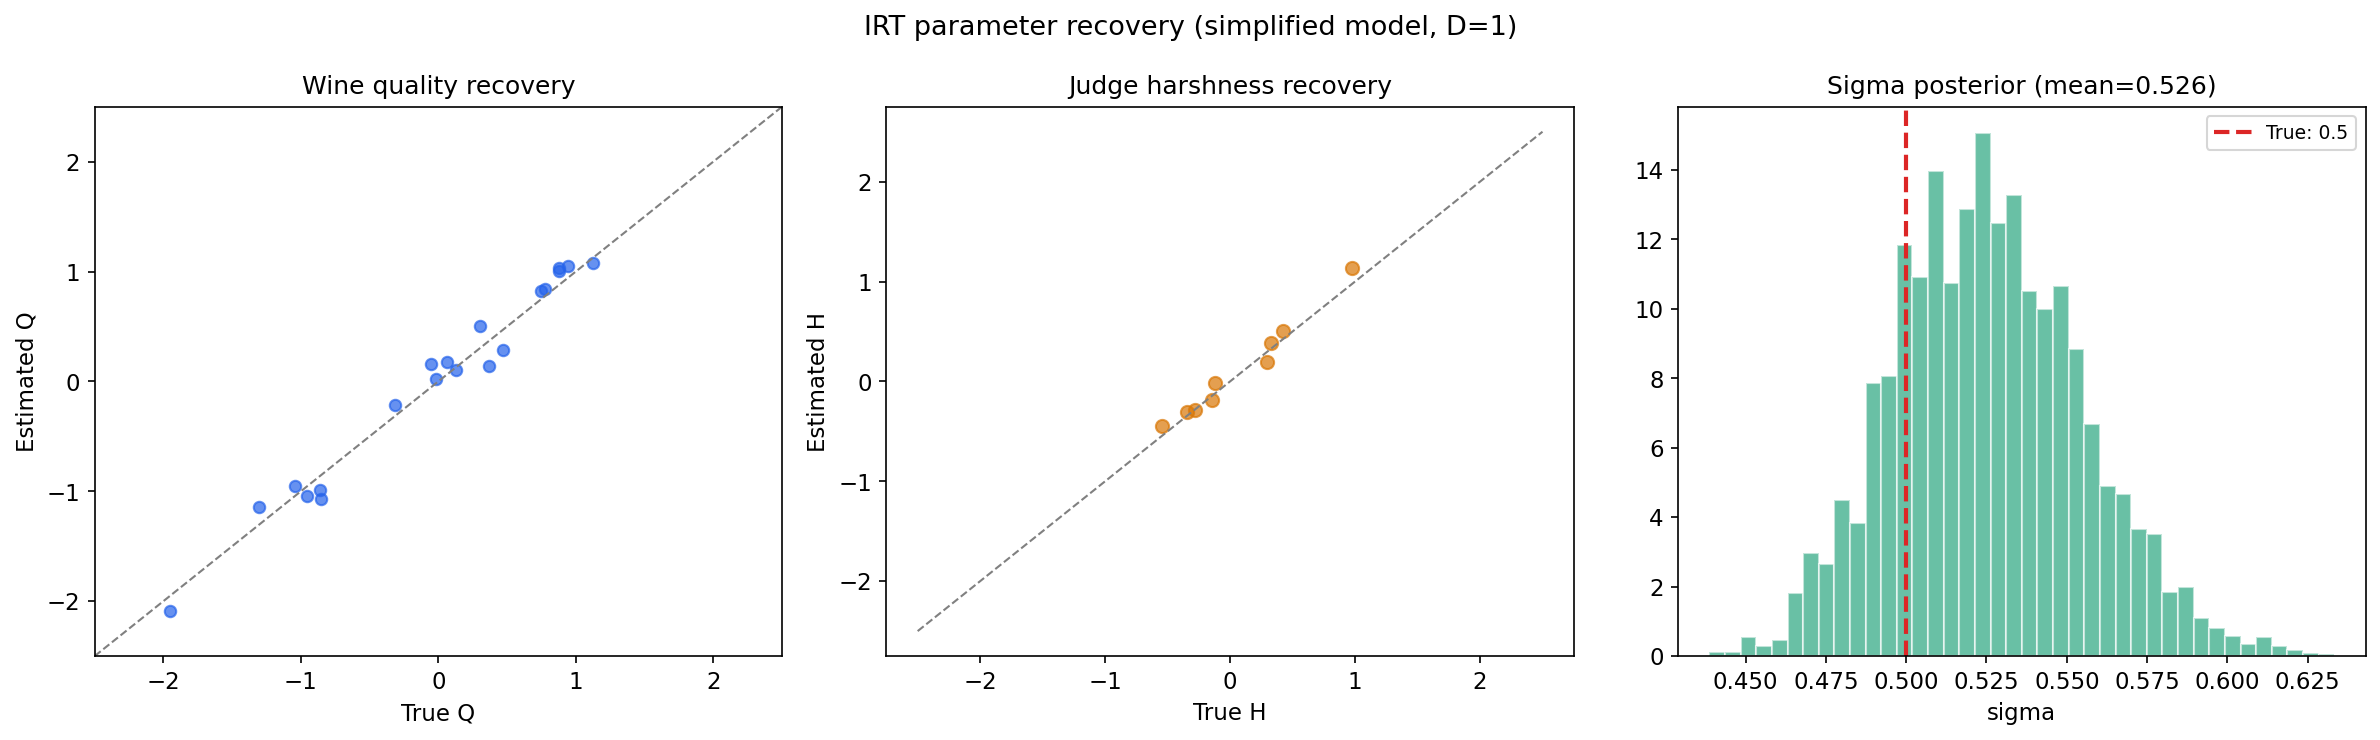

Quality recovery: r = 0.989
Harshness recovery: r = 0.989
Sigma: true = 0.500, estimated = 0.526


In [9]:
# Extract posteriors and compare to truth
warmup_wine = 1000

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Wine quality recovery
Q_post = np.mean([chains_wine[c, warmup_wine:, :n_w] for c in range(2)], axis=(0, 1))
axes[0].scatter(wine_data["Q_true"], Q_post, color=C_POSTERIOR, s=30, alpha=0.7)
lims = [-2.5, 2.5]
axes[0].plot(lims, lims, "--", color="gray", linewidth=1)
axes[0].set_xlabel("True Q"); axes[0].set_ylabel("Estimated Q")
axes[0].set_title("Wine quality recovery")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)

# Judge harshness recovery
H_post = np.mean([chains_wine[c, warmup_wine:, n_w:n_w+n_j] for c in range(2)], axis=(0, 1))
axes[1].scatter(wine_data["H_true"], H_post, color=C_ACCENT, s=40, alpha=0.7)
axes[1].plot(lims, lims, "--", color="gray", linewidth=1)
axes[1].set_xlabel("True H"); axes[1].set_ylabel("Estimated H")
axes[1].set_title("Judge harshness recovery")

# Sigma recovery
sigma_post = np.exp(np.concatenate([chains_wine[c, warmup_wine:, -1] for c in range(2)]))
axes[2].hist(sigma_post, bins=40, density=True, alpha=0.6, color=C_DATA, edgecolor="white")
axes[2].axvline(wine_data["sigma_true"], color=C_LIKELIHOOD, linewidth=2, linestyle="--",
                label=f"True: {wine_data['sigma_true']}")
axes[2].set_title(f"Sigma posterior (mean={sigma_post.mean():.3f})")
axes[2].set_xlabel("sigma"); axes[2].legend(fontsize=9)

plt.suptitle("IRT parameter recovery (simplified model, D=1)", fontsize=13)
plt.tight_layout()
plt.show()

r_Q = np.corrcoef(wine_data["Q_true"], Q_post)[0, 1]
r_H = np.corrcoef(wine_data["H_true"], H_post)[0, 1]
print(f"Quality recovery: r = {r_Q:.3f}")
print(f"Harshness recovery: r = {r_H:.3f}")
print(f"Sigma: true = {wine_data['sigma_true']:.3f}, estimated = {sigma_post.mean():.3f}")

---

# Part 2: Applied Exercises with Slovenian Data

MCMC and IRT concepts applied to real datasets.

In [10]:
re = pd.read_csv(DATA_DIR / "sr2026_real_estate.csv", parse_dates=["date"])
forensic = pd.read_csv(DATA_DIR / "sr2026_forensic_audio.csv")
mun = pd.read_csv(DATA_DIR / "sr2026_municipality_panel.csv")

YEAR_MIN = 2022

## Exercise 1: Metropolis on Real Estate Beta-Binomial

Revisit the A01 problem (proportion of Ljubljana apartments above 3,000 EUR/m2) using MCMC instead of the analytical Beta-Binomial. The posterior should match the exact solution.

Ljubljana apartments (2022+): 3,635
Above 3,000 EUR/m2: 2,723 (74.9%)

Running 4 Metropolis chains...
Acceptance rate: 61.30%
Acceptance rate: 61.18%
Acceptance rate: 59.74%
Acceptance rate: 61.42%


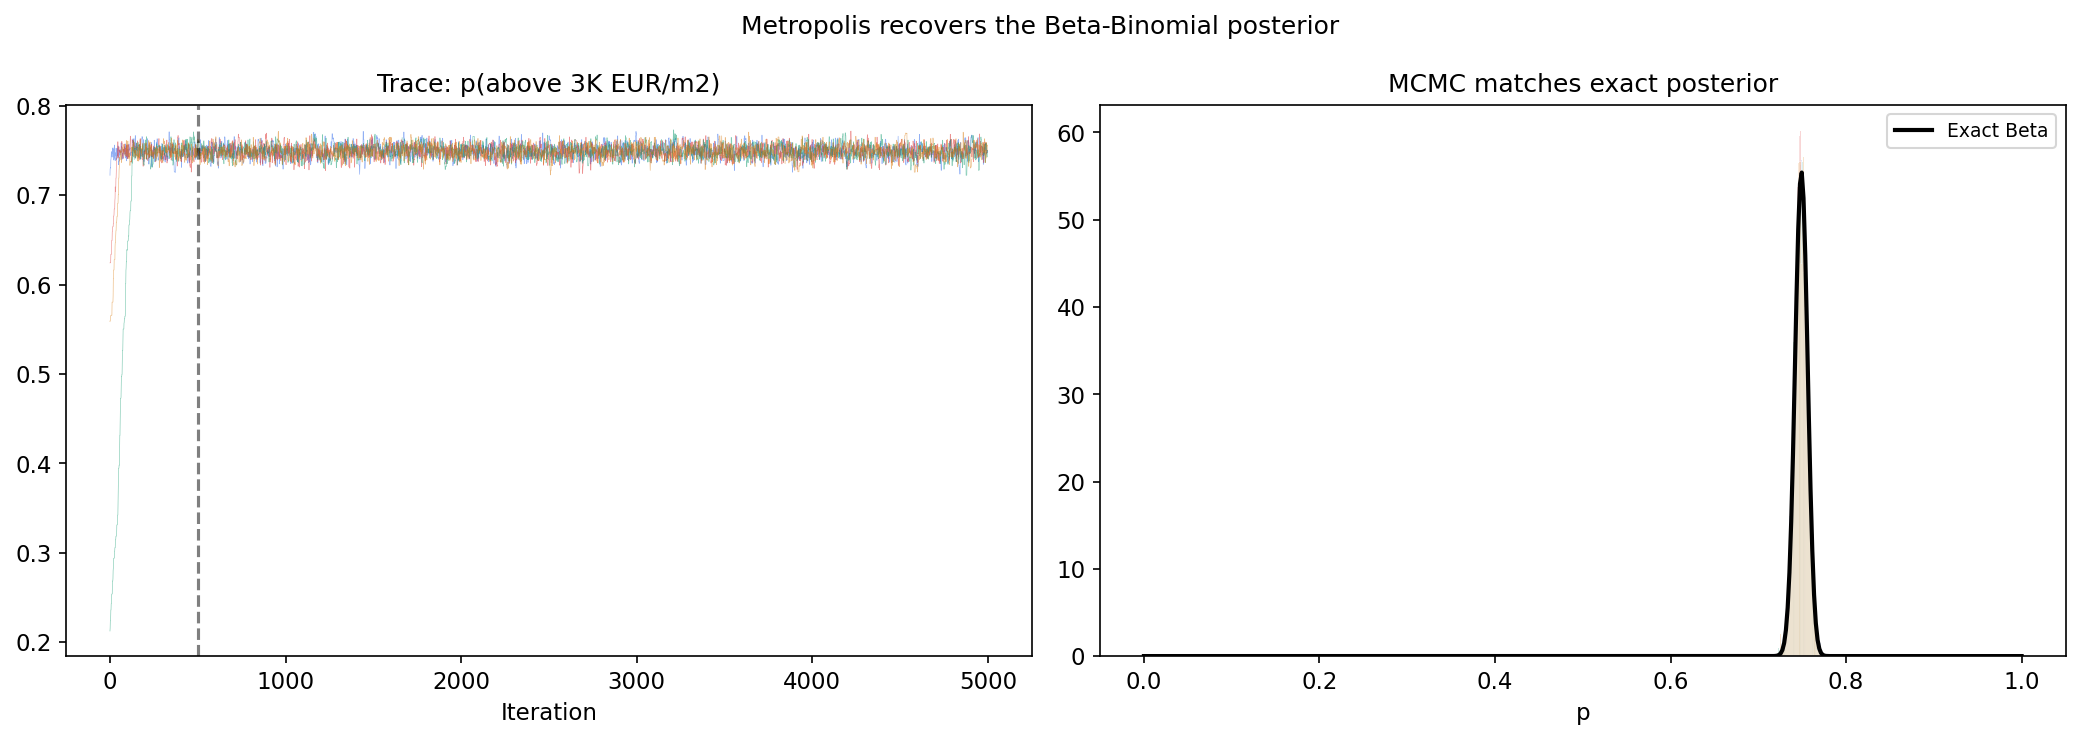

Exact mean: 0.74897
MCMC mean:  0.74886
R-hat: 1.0003


In [11]:
# Ljubljana apartments, recent years
lj_apt = re[
    (re["year"] >= YEAR_MIN)
    & (re["municipality"] == "LJUBLJANA")
    & (re["property_type"] == "apartment")
    & re["price_per_m2"].notna()
].copy()

THRESHOLD = 3_000
n_above = (lj_apt["price_per_m2"] > THRESHOLD).sum()
n_total = len(lj_apt)
print(f"Ljubljana apartments ({YEAR_MIN}+): {n_total:,}")
print(f"Above {THRESHOLD:,} EUR/m2: {n_above:,} ({n_above/n_total:.1%})")

# Log posterior for p (Beta-Binomial)
def lp_binomial(params):
    p = params[0]
    if p <= 0 or p >= 1:
        return -np.inf
    ll = n_above * np.log(p) + (n_total - n_above) * np.log(1 - p)
    lp = 0.0  # flat prior
    return ll + lp

# Run 4 chains
print("\nRunning 4 Metropolis chains...")
chains_binom = []
for c in range(4):
    start = np.array([np.random.default_rng(SEED + c).uniform(0.1, 0.9)])
    chain = metropolis(lp_binomial, start, n_samples=N_SAMPLES, proposal_sd=0.01,
                        seed=SEED + c)
    chains_binom.append(chain[:, 0])

chains_binom = np.array(chains_binom)
warmup_b = 500

# Compare to exact Beta posterior
p_grid = np.linspace(0, 1, 500)
exact_post = stats.beta(n_above + 1, n_total - n_above + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trace
for c in range(4):
    axes[0].plot(chains_binom[c], alpha=0.5, linewidth=0.3, color=CHAIN_COLORS[c])
axes[0].axvline(warmup_b, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("Trace: p(above 3K EUR/m2)")
axes[0].set_xlabel("Iteration")

# Density vs exact
for c in range(4):
    axes[1].hist(chains_binom[c, warmup_b:], bins=40, density=True, alpha=0.25,
                 color=CHAIN_COLORS[c], edgecolor="white")
axes[1].plot(p_grid, exact_post.pdf(p_grid), color="black", linewidth=2, label="Exact Beta")
axes[1].set_title("MCMC matches exact posterior")
axes[1].set_xlabel("p"); axes[1].legend(fontsize=9)

plt.suptitle("Metropolis recovers the Beta-Binomial posterior", fontsize=12)
plt.tight_layout()
plt.show()

rhat_b = compute_rhat(chains_binom, warmup=warmup_b)
mcmc_mean = np.mean(chains_binom[:, warmup_b:])
print(f"Exact mean: {exact_post.mean():.5f}")
print(f"MCMC mean:  {mcmc_mean:.5f}")
print(f"R-hat: {rhat_b:.4f}")

## Exercise 2: Forensic IRT — Multi-System Evaluation

**IRT for forensic systems:** Multiple detection systems (raters) evaluate the same set of recordings (items). Each system has its own discrimination and calibration bias.

Simulate a multi-system evaluation and recover system-level parameters. This connects to the $C_\text{llr}$ framework: discrimination maps to $C_\text{llr,min}$, calibration bias maps to $C_\text{llr,cal}$.

Fitting forensic IRT (simplified, D=1)...
Acceptance rate: 64.18%


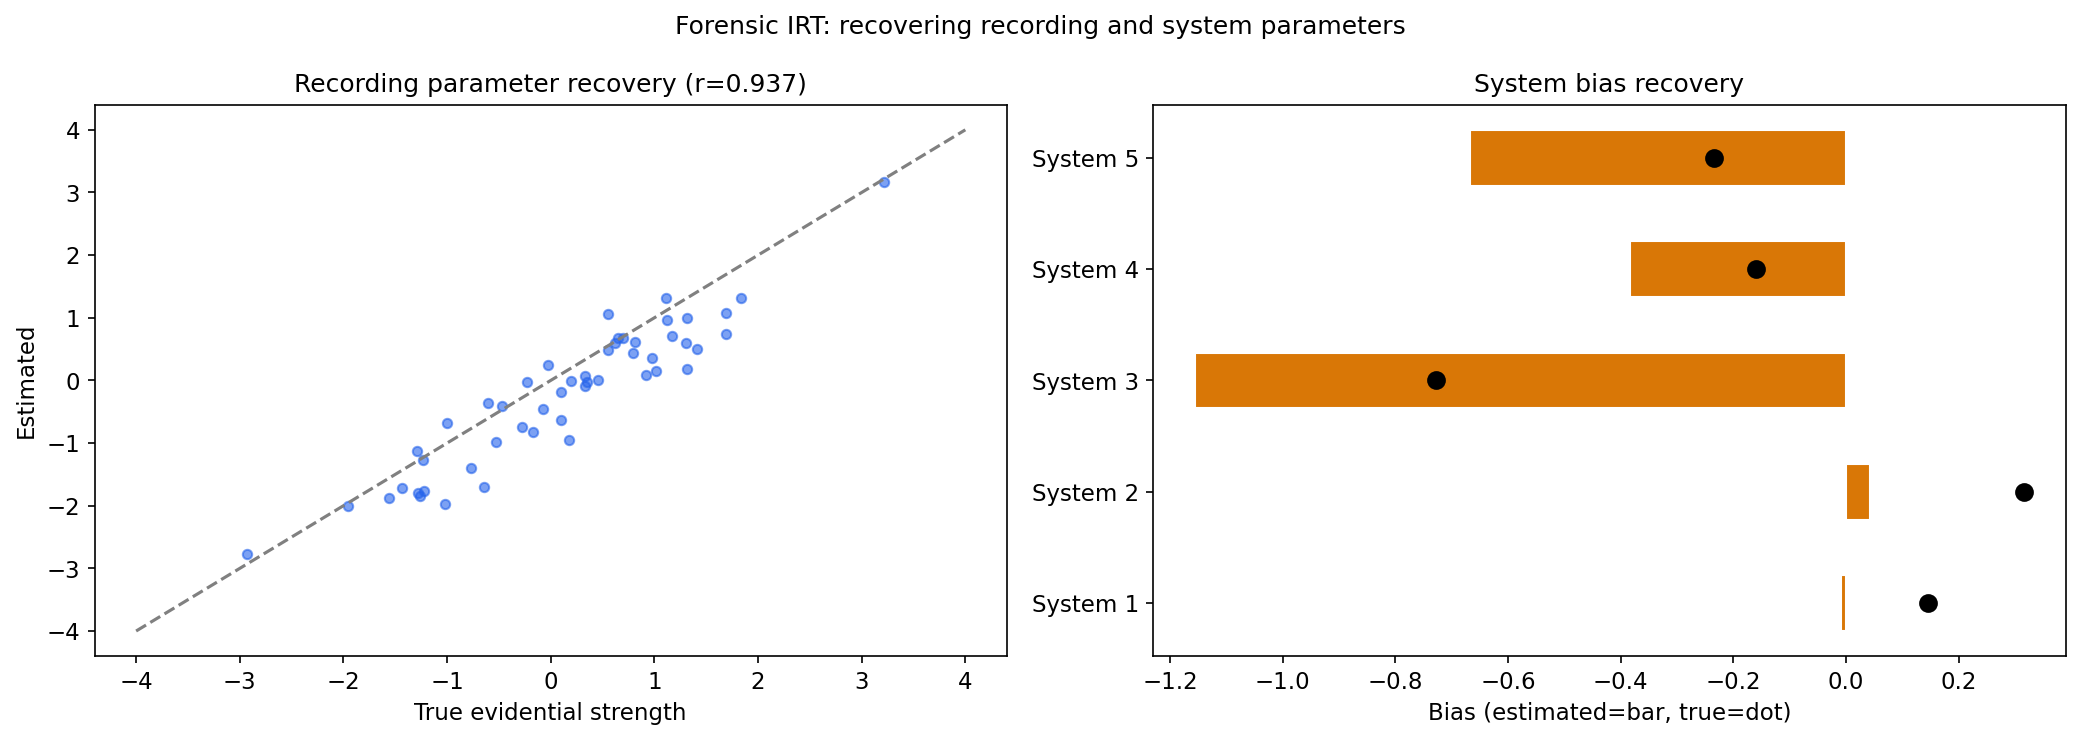

Each system's bias corresponds to Cllr_cal: how much it over/understates evidence.
The recording parameters correspond to true evidential strength.


In [12]:
# Simulate forensic multi-system evaluation
def sim_forensic_irt(
    n_recordings: int = 50,
    n_systems: int = 5,
    seed: int = SEED,
) -> dict:
    """Simulate forensic multi-system evaluation as IRT.

    Items = recordings (with true evidential strength).
    Raters = forensic systems (with discrimination and bias).

    Args:
        n_recordings: Number of recordings.
        n_systems: Number of systems.
        seed: Random seed.

    Returns:
        Dict with scores and true parameters.
    """
    rng = np.random.default_rng(seed)
    # True evidential strength (positive = same source, negative = different)
    E_true = rng.normal(0, 1.5, size=n_recordings)
    # System bias (harshness analog)
    B_true = rng.normal(0, 0.5, size=n_systems)
    # System discrimination
    D_true = rng.lognormal(0, 0.4, size=n_systems)
    sigma_true = 0.8

    rec_idx = np.tile(np.arange(n_recordings), n_systems)
    sys_idx = np.repeat(np.arange(n_systems), n_recordings)

    mu = D_true[sys_idx] * E_true[rec_idx] - B_true[sys_idx]
    scores = mu + rng.normal(0, sigma_true, size=len(mu))

    return {"scores": scores, "rec_idx": rec_idx, "sys_idx": sys_idx,
            "E_true": E_true, "B_true": B_true, "D_true": D_true,
            "sigma_true": sigma_true, "n_rec": n_recordings, "n_sys": n_systems}

for_irt = sim_forensic_irt()

# Fit simplified model (D=1) via Metropolis
n_r, n_s = for_irt["n_rec"], for_irt["n_sys"]

def lp_forensic(params):
    E = params[:n_r]
    B = params[n_r:n_r + n_s]
    log_sigma = params[-1]
    sigma = np.exp(log_sigma)
    if sigma <= 0 or sigma > 10:
        return -np.inf
    mu = E[for_irt["rec_idx"]] - B[for_irt["sys_idx"]]
    ll = np.sum(stats.norm.logpdf(for_irt["scores"], mu, sigma))
    lp = np.sum(stats.norm.logpdf(E, 0, 1.5)) + np.sum(stats.norm.logpdf(B, 0, 1))
    lp += stats.expon.logpdf(sigma, scale=1) + log_sigma
    return ll + lp

print("Fitting forensic IRT (simplified, D=1)...")
start_f = np.zeros(n_r + n_s + 1)
start_f[-1] = np.log(0.8)
chain_for = metropolis(lp_forensic, start_f, n_samples=N_SAMPLES, proposal_sd=0.03,
                        seed=SEED)

warmup_f = 1500
E_post = chain_for[warmup_f:, :n_r].mean(axis=0)
B_post = chain_for[warmup_f:, n_r:n_r+n_s].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(for_irt["E_true"], E_post, color=C_POSTERIOR, s=20, alpha=0.6)
axes[0].plot([-4, 4], [-4, 4], "--", color="gray")
axes[0].set_xlabel("True evidential strength")
axes[0].set_ylabel("Estimated")
axes[0].set_title(f"Recording parameter recovery (r={np.corrcoef(for_irt['E_true'], E_post)[0,1]:.3f})")

axes[1].barh(range(n_s), B_post, color=C_ACCENT, height=0.5, edgecolor="white")
for i in range(n_s):
    axes[1].plot(for_irt["B_true"][i], i, "ko", markersize=8)
axes[1].set_yticks(range(n_s))
axes[1].set_yticklabels([f"System {i+1}" for i in range(n_s)])
axes[1].set_xlabel("Bias (estimated=bar, true=dot)")
axes[1].set_title("System bias recovery")

plt.suptitle("Forensic IRT: recovering recording and system parameters", fontsize=12)
plt.tight_layout()
plt.show()

print("Each system's bias corresponds to Cllr_cal: how much it over/understates evidence.")
print("The recording parameters correspond to true evidential strength.")

## Exercise 3: Judge/System Discrimination Curves

Visualize the discrimination parameter as an Item Characteristic Curve (ICC). Steep = discriminating (separates quality well). Flat = non-discriminating.

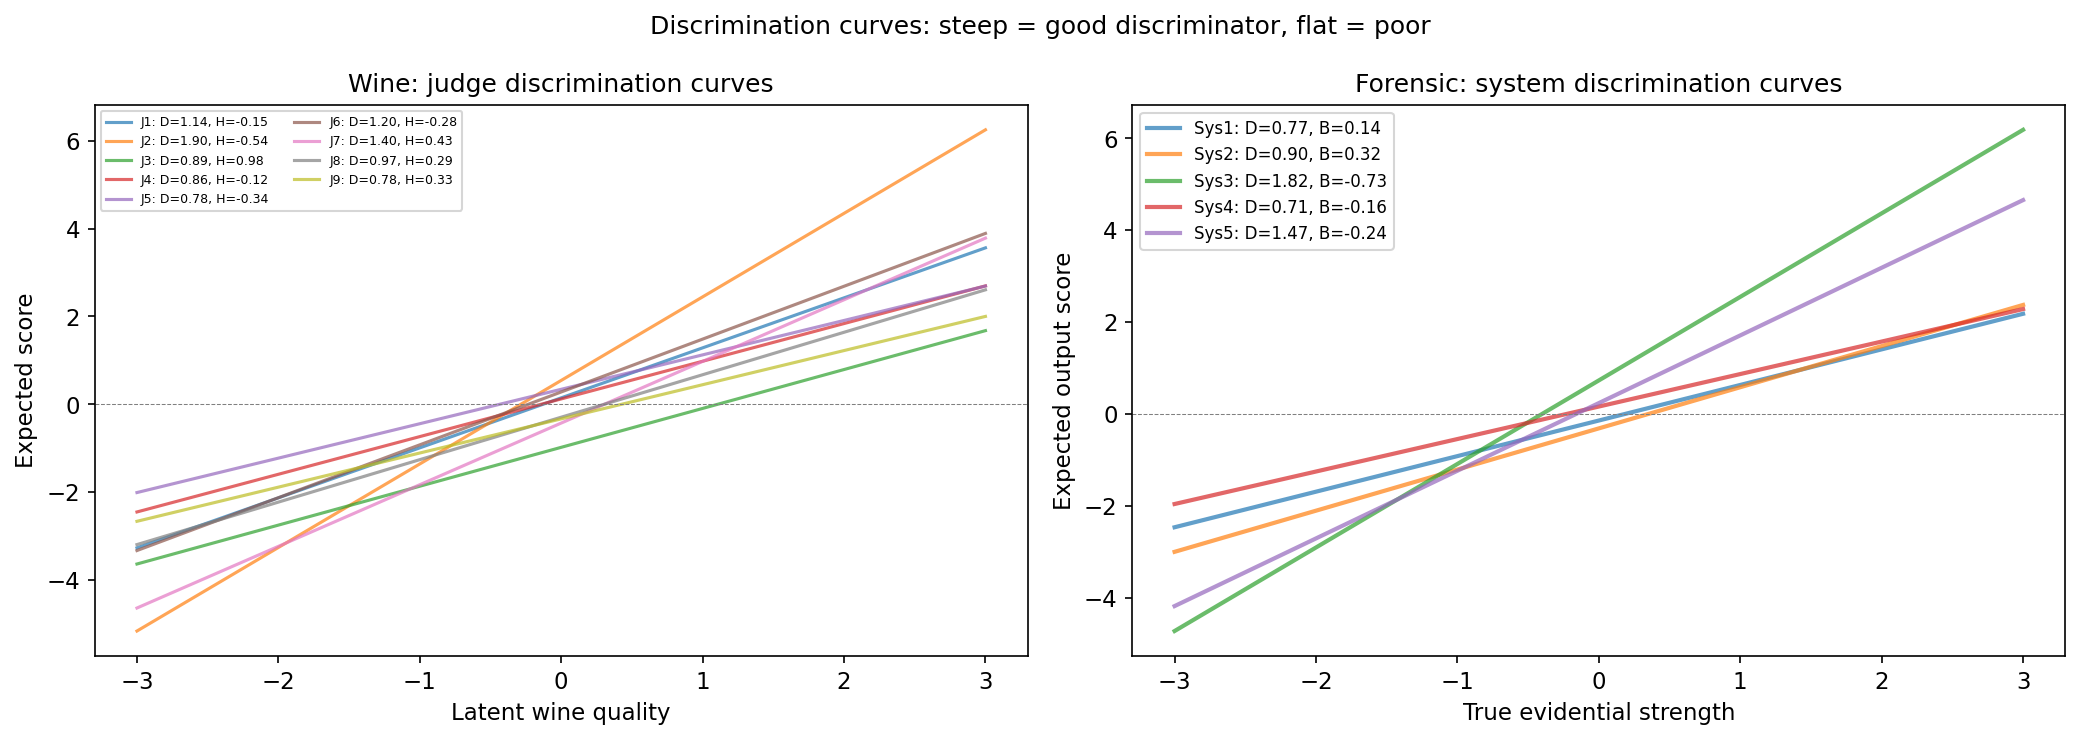

Steep curves (high D): the judge/system sharply differentiates quality levels.
Flat curves (low D): similar scores regardless of quality.
In forensics, high D maps to low Cllr_min (good raw discrimination).


In [13]:
# Plot discrimination curves for the simulated wine judges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wine judges
q_range = np.linspace(-3, 3, 100)
for j in range(wine_data["n_judges"]):
    d = wine_data["D_true"][j]
    h = wine_data["H_true"][j]
    mu = d * q_range - h
    axes[0].plot(q_range, mu, linewidth=1.5, alpha=0.7,
                 label=f"J{j+1}: D={d:.2f}, H={h:.2f}")
axes[0].set_xlabel("Latent wine quality")
axes[0].set_ylabel("Expected score")
axes[0].set_title("Wine: judge discrimination curves")
axes[0].legend(fontsize=6, ncol=2)
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")

# Forensic systems
for s in range(for_irt["n_sys"]):
    d = for_irt["D_true"][s]
    b = for_irt["B_true"][s]
    mu = d * q_range - b
    axes[1].plot(q_range, mu, linewidth=2, alpha=0.7,
                 label=f"Sys{s+1}: D={d:.2f}, B={b:.2f}")
axes[1].set_xlabel("True evidential strength")
axes[1].set_ylabel("Expected output score")
axes[1].set_title("Forensic: system discrimination curves")
axes[1].legend(fontsize=8)
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.suptitle("Discrimination curves: steep = good discriminator, flat = poor", fontsize=12)
plt.tight_layout()
plt.show()

print("Steep curves (high D): the judge/system sharply differentiates quality levels.")
print("Flat curves (low D): similar scores regardless of quality.")
print("In forensics, high D maps to low Cllr_min (good raw discrimination).")

## Exercise 4: MCMC on Municipality Salary-Price Model

Fit the salary $\rightarrow$ price regression from A06 using Metropolis instead of quadratic approximation. Verify that MCMC recovers the same posterior.

Running 4 chains on municipality model...
Acceptance rate: 32.92%
Acceptance rate: 33.26%
Acceptance rate: 33.88%
Acceptance rate: 33.86%


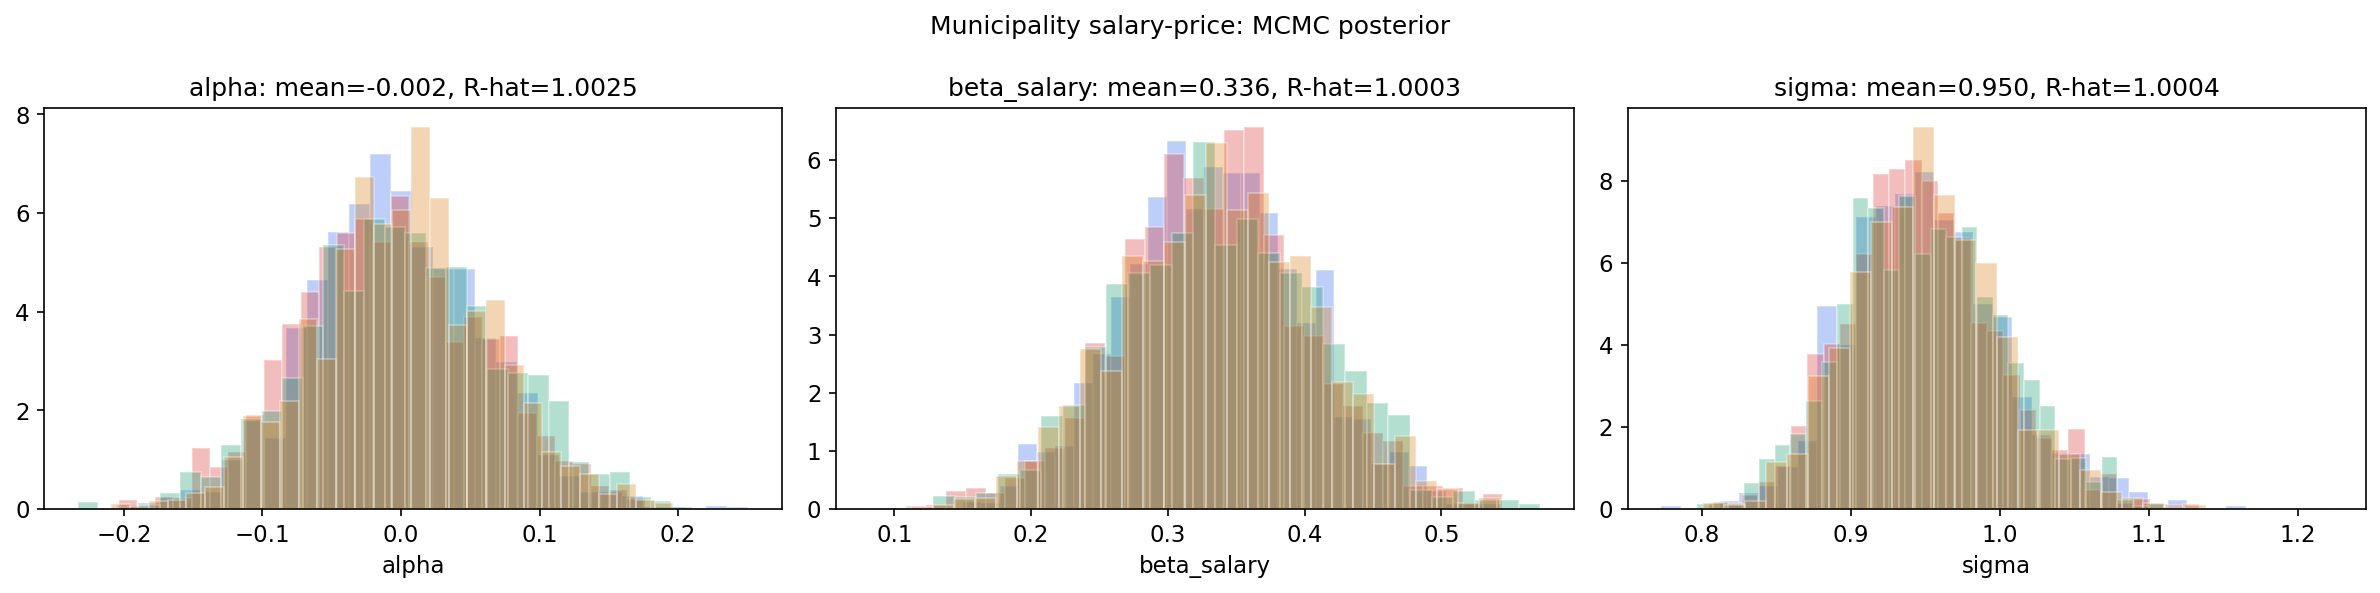

beta_salary (MCMC): 0.336
Should match the quadratic approximation from A06 notebooks.


In [14]:
# Municipality data
latest_year = mun["year"].max()
mun_clean = mun[
    (mun["year"] == latest_year)
    & mun["avg_gross_salary"].notna()
    & mun["median_price_m2"].notna()
].copy()

def standardize(x):
    return (x - np.nanmean(x)) / np.nanstd(x)

sal_s = standardize(mun_clean["avg_gross_salary"].values)
pri_s = standardize(mun_clean["median_price_m2"].values)

def lp_mun(params):
    alpha, beta, log_sigma = params
    sigma = np.exp(log_sigma)
    if sigma <= 0:
        return -np.inf
    mu = alpha + beta * sal_s
    ll = np.sum(stats.norm.logpdf(pri_s, mu, sigma))
    lp = stats.norm.logpdf(alpha, 0, 0.2) + stats.norm.logpdf(beta, 0, 0.5)
    lp += stats.expon.logpdf(sigma, scale=1) + log_sigma
    return ll + lp

print("Running 4 chains on municipality model...")
chains_mun = []
for c in range(4):
    start = np.array([0.0, 0.0, np.log(1.0)]) + np.random.default_rng(SEED + c).normal(0, 0.3, 3)
    chain = metropolis(lp_mun, start, n_samples=N_SAMPLES, proposal_sd=0.08,
                        seed=SEED + c)
    chains_mun.append(chain)
chains_mun = np.array(chains_mun)

warmup_m = 1000

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
param_labels = ["alpha", "beta_salary", "sigma"]

for p in range(3):
    vals = chains_mun[:, warmup_m:, p]
    if p == 2:
        vals = np.exp(vals)  # log_sigma -> sigma
    for c in range(4):
        axes[p].hist(vals[c], bins=30, density=True, alpha=0.3,
                     color=CHAIN_COLORS[c], edgecolor="white")
    rhat = compute_rhat(chains_mun[:, :, p], warmup=warmup_m)
    mean_val = vals[:, :].mean()
    axes[p].set_title(f"{param_labels[p]}: mean={mean_val:.3f}, R-hat={rhat:.4f}")
    axes[p].set_xlabel(param_labels[p])

plt.suptitle("Municipality salary-price: MCMC posterior", fontsize=12)
plt.tight_layout()
plt.show()

beta_mcmc = chains_mun[:, warmup_m:, 1].mean()
print(f"beta_salary (MCMC): {beta_mcmc:.3f}")
print("Should match the quadratic approximation from A06 notebooks.")

---

# Key Takeaways

1. **MCMC works where quadratic approximation fails.** For the Beta-Binomial (E1), MCMC recovers the exact posterior. For the IRT model (39 latent parameters), quadratic approximation would struggle but MCMC handles it naturally.

2. **Always run multiple chains.** A single chain can appear converged while stuck in a local mode. Four chains from dispersed starts, checked with R-hat and ESS, catch non-convergence.

3. **Bad chains are detectable.** Tiny proposal SD produces drifting, stuck chains. R-hat > 1.01 and ESS < 100 flag the problem before you interpret garbage posteriors.

4. **IRT decomposes scores into items and raters.** Wine quality vs judge bias. Recording evidential strength vs system calibration. Property value vs appraiser tendency. The same model structure across domains.

5. **Discrimination curves are ICCs.** Steep = the rater/system differentiates quality well. Flat = it does not. In forensics, high discrimination = low $C_\text{llr,min}$.

6. **MCMC on simple models validates understanding.** Using Metropolis on the Beta-Binomial confirms the exact analytical result. Using it on the municipality regression confirms the quadratic approximation. Build confidence with known answers before tackling complex models.

**Next:** [[Lecture A09]] introduces hierarchical (multilevel) models, where MCMC becomes essential.